# Image clustering using GPT-4o

In [98]:
import pandas as pd
from pathlib import Path

from AI_representation_bias_in_farming import module5_extract_pic_feature_words

# import the megadata dataframe
megadata_file = Path("..") / "results" / "megadata" / "image_megadata.csv"
megadata = pd.read_csv(megadata_file, header=0)

# import manual cluster check note
manual_correction_file = Path("..") / "results" / "megadata" / "outlier_image_manual_correction.csv"
manual_correction = pd.read_csv(manual_correction_file, header=0)

# Create a list of outdoor values to check, combine these and call it all to be "outdoor"
outdoor_values = ['pasture', 'pasture_or_mud']
megadata["GPT4o_cluster"] = megadata["GPT4o_cluster"].replace(outdoor_values, "outdoor")\
    
# update the GPT4o_cluster based on my manual check results and cluster label corrections
megadata2 = pd.merge(megadata, manual_correction, on =("file", "GPT4o_cluster", "GPT4o_cluster_explanation"), how = "left")
megadata2['GPT4o_cluster'] = megadata2['GPT4o_cluster'].where(
    pd.isna(megadata2['change_to_cluster']), 
    megadata2['change_to_cluster']
)

megadata2_file = Path("..") / "results" / "megadata" / "image_megadata_post_manual_fix.csv"
megadata2.to_csv(megadata2_file, index = False)

# what's the percentage of images that got manually corrected? 
manual_pct = round(len(manual_correction)/len(megadata2), 5)
print(f"The percentage of images got manually corrected is: {manual_pct}")

# what's the percentage of images that got manually corrected? 
metal_railing_count = megadata2['manual_note'].str.contains('metal', na=False).sum()
unclear_count = megadata2['manual_note'].str.contains('unclear', na=False).sum()
other_image_count = len(megadata2[megadata2['GPT4o_cluster'] == "other"])
manual_check_total = len(manual_correction)
metal_railing_pct = round((metal_railing_count/manual_check_total), 5)
unclear_pct = round((unclear_count/manual_check_total), 5)
print(f"The percentage of images in the 'other' category that contains animals housed behind metal railings but are outdoors is: {metal_railing_pct}")
print(f"The percentage of images in the 'other' category, because the background is too unclear to judge is: {unclear_pct}")


The percentage of images got manually corrected is: 0.04773
The percentage of images in the 'other' category that contains animals housed behind metal railings but are outdoors is: 0.41667
The percentage of images in the 'other' category, because the background is too unclear to judge is: 0.2381


In [ ]:
# For ease of visualization to see how well the clustering performs. 
# I exported images belonging to each cluster into seperate folders. 
# Images are reduced to 50% quality as this is just an exploratory 
# analysis to see how legit the clustering labels are

# below are based on GPT 4o's original cluster labels, fully automated
source_base = Path("..") / "results"
dest_base = Path("..") / "results" / "cluster"

module5_extract_pic_feature_words.cluster_farm_images(
    megadata,
    source_base,
    dest_base
)

In [43]:
# For ease of visualization to see how well the clustering performs. 
# I exported images belonging to each cluster into seperate folders. 
# Images are reduced to 50% quality as this is just an exploratory 
# analysis to see how legit the clustering labels are

# below are based on GPT 4o's original cluster labels, 
# and my manual cluster label corrections after checking all images myself.
source_base = Path("..") / "results"
dest_base = Path("..") / "results" / "cluster_post_manual_fix"

module5_extract_pic_feature_words.cluster_farm_images(
    megadata2,
    source_base,
    dest_base
)


In [113]:
# summary
cluster_summary = (
    module5_extract_pic_feature_words.summarize_clusters(megadata2, output_file="cluster_summary.csv")
)

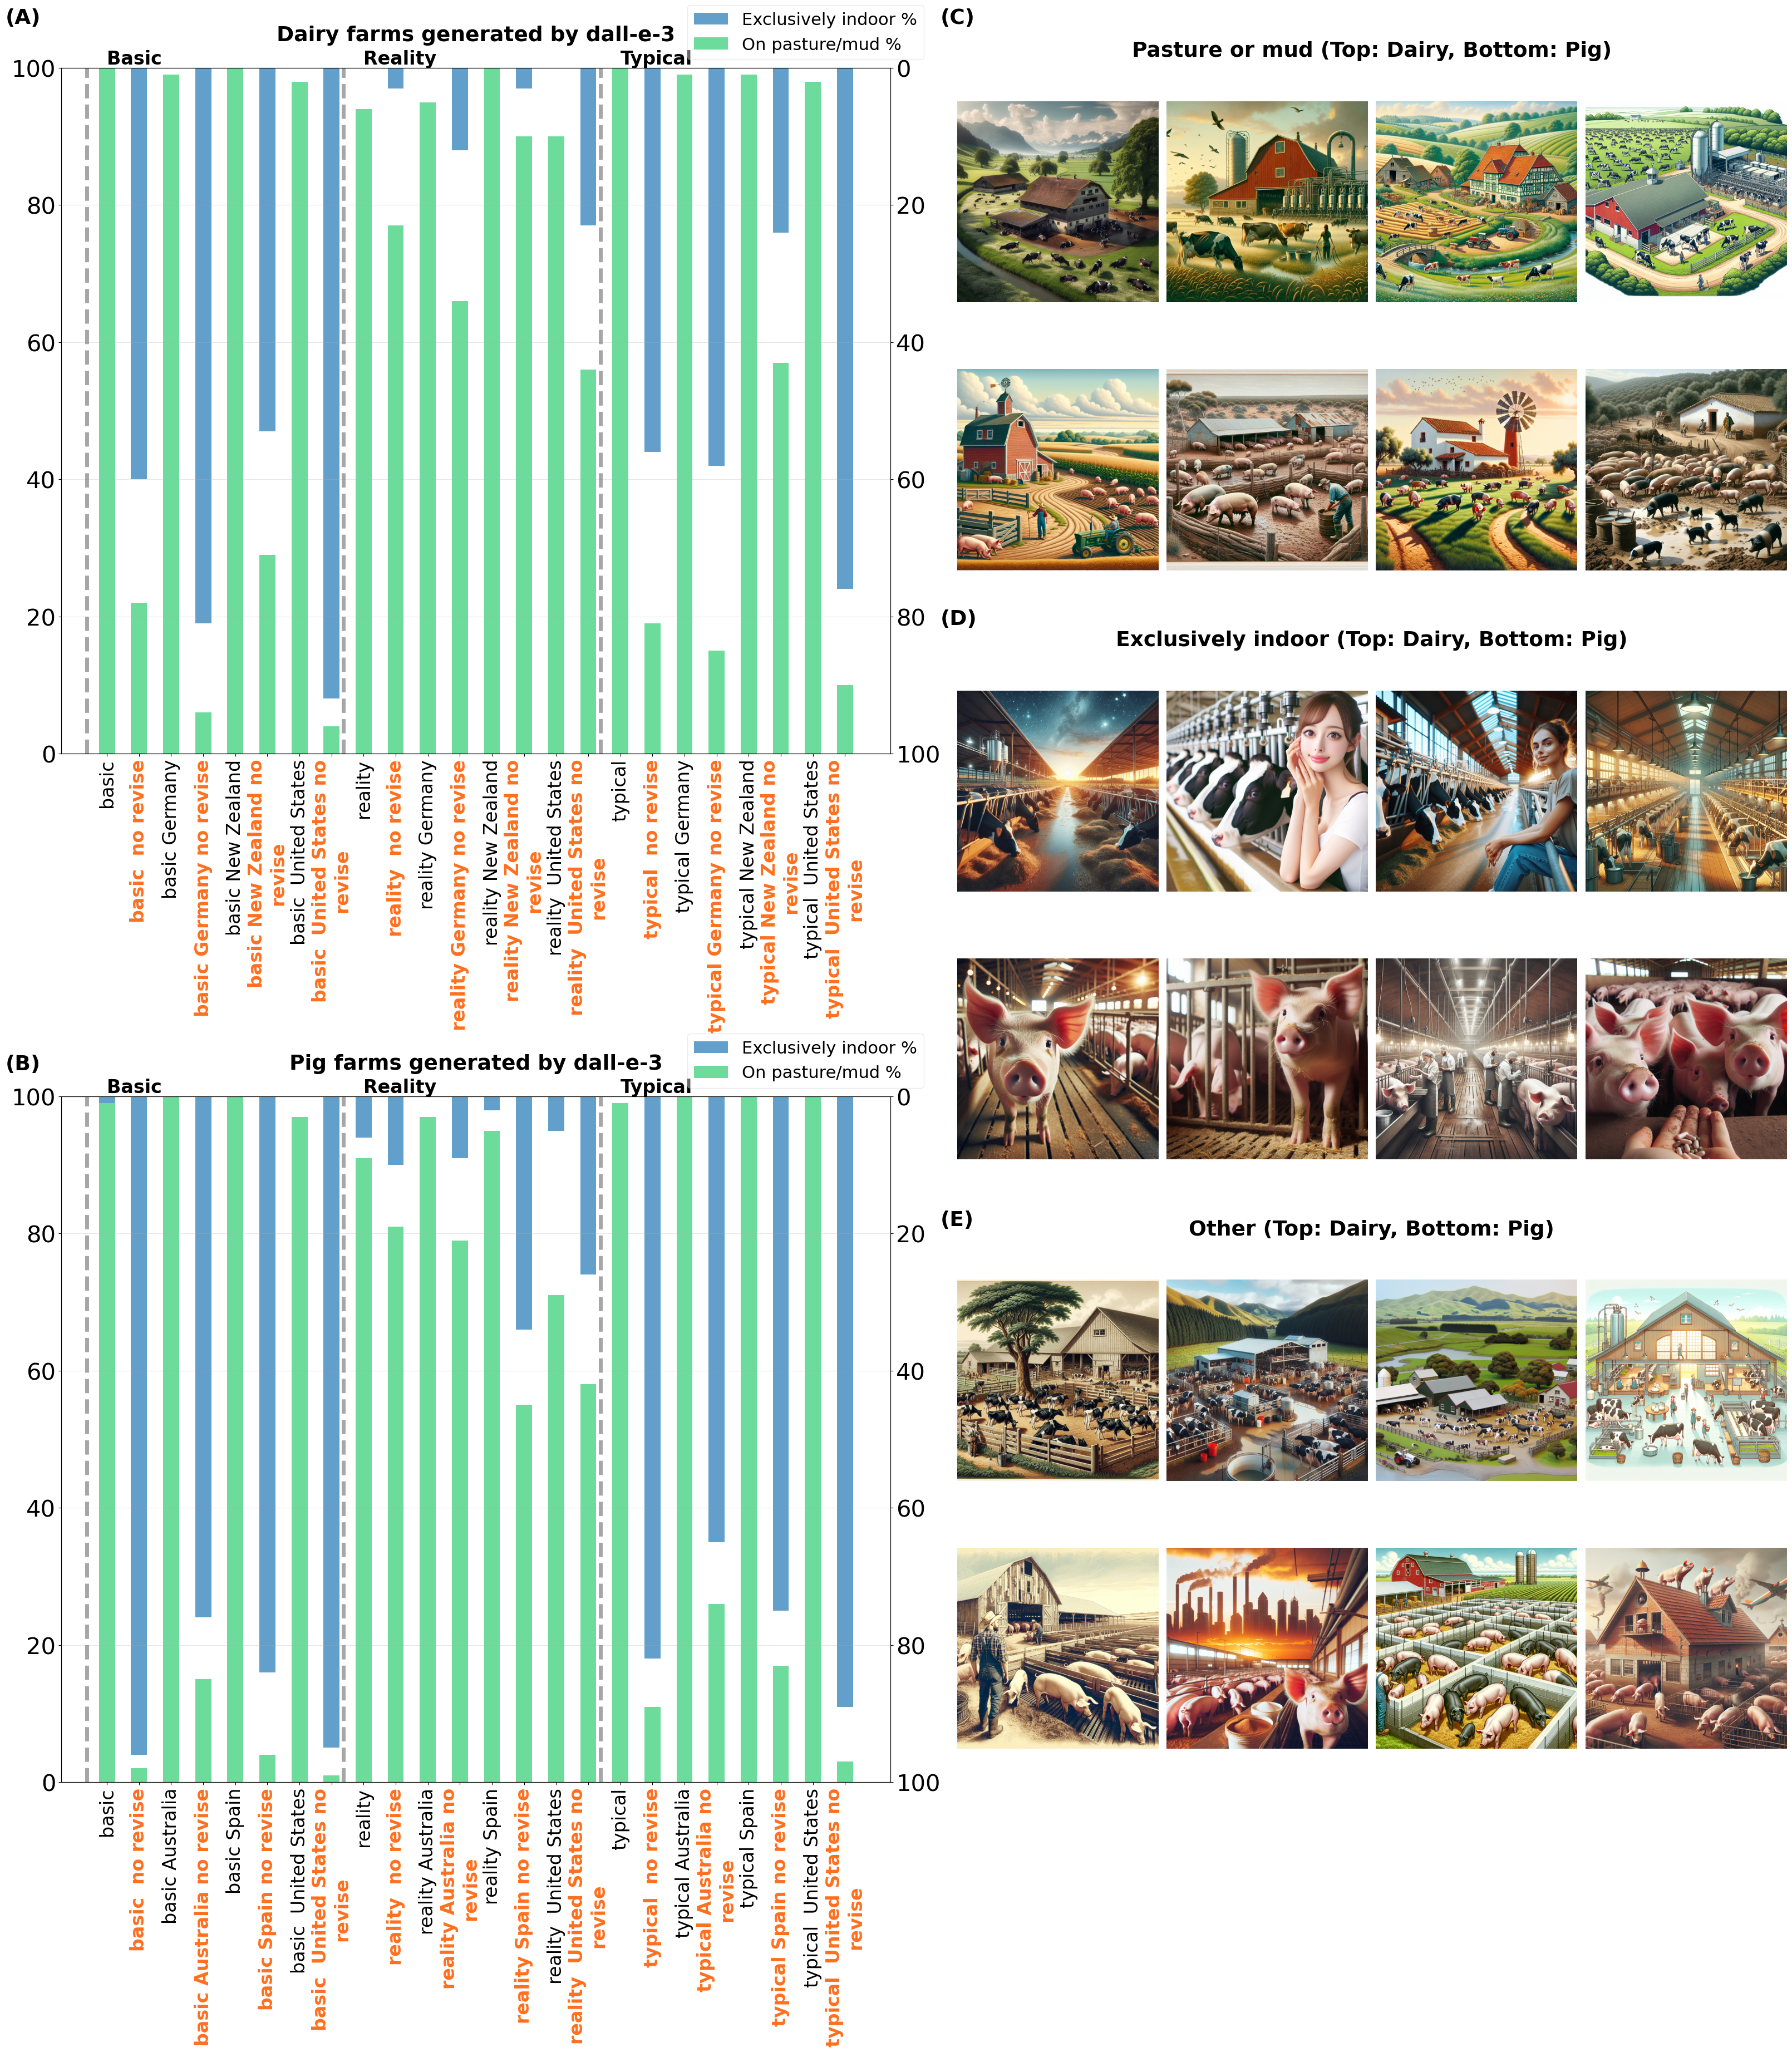

In [114]:
source_base = Path("..") / "results"
output_path = Path("..") / "results" / "plots" / "cluster_summary_dall-e-3.png"
model = "dall-e-3"
fig = module5_extract_pic_feature_words.save_plot_grid(cluster_summary, output_path, megadata2, source_base, model, num_images=8, images_per_row= 4, random_seed=21)
fig